# Pipeline d'un modele d'IA avec PyTorch
### + charger un modele pre-entraine (Hugging Face / Kaggle)

 Ici on construit un **pipeline complet de A a Z** : donnees -> modele -> entrainement -> evaluation -> sauvegarde. Puis on montre comment, en competition, **partir d'un modele deja entraine** au lieu de tout recreer soi-meme, via Hugging Face ou Kaggle selon ou se trouve la ressource.

Plan :
1. Pipeline complet "from scratch" avec PyTorch (sur MNIST, classification d'images)
2. Charger un modele pre-entraine avec Hugging Face (`transformers`)
3. Charger un dataset / modele avec Kaggle (`kagglehub`)
4. Section debug : des cellules avec des bugs volontaires a trouver et corriger
5. Exercices finaux

**Note** : la partie 1 telecharge MNIST (necessite internet). Si pas de connexion en salle, un fallback avec donnees synthetiques est indique en commentaire dans la cellule de chargement.

**Quand utiliser Hugging Face vs Kaggle en competition ?**
- **Hugging Face** : quand tu as besoin d'un modele pre-entraine (texte, image, audio) prêt a l'emploi ou a fine-tuner la reference pour les modeles.
- **Kaggle** : quand la competition fournit un dataset specifique sur Kaggle, ou quand tu cherches un modele/notebook de reference deja utilise sur une competition similaire la reference pour les datasets et notebooks de competition.

## Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

print("torch:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device utilise:", device)

torch: 2.5.1+cu121
device utilise: cuda


## 1. Pipeline complet "from scratch" (sur MNIST)

Le pipeline complet d'un projet de deep learning suit toujours les memes grandes etapes, qu'il s'agisse d'un projet jouet ou d'un projet de competition :

```
donnees brutes -> Dataset/DataLoader -> modele -> boucle d'entrainement
    -> validation -> metriques -> sauvegarde du modele entraine
```

**Analogie** : c'est comme monter un restaurant. On approvisionne (donnees), on organise la cuisine par postes (DataLoader = livrer les ingredients par lots), on definit les recettes (modele), on s'entraine en cuisine test (entrainement), un client gouteur donne son avis (validation), on note la satisfaction (metriques), et on ecrit la recette finale dans un livre pour la reproduire (sauvegarde).

On utilise MNIST (images de chiffres manuscrits 0-9, 28x28 pixels) : petit, rapide a entrainer, standard pour apprendre le pipeline complet.

### 1.1 Chargement des donnees

In [2]:
import torchvision
from torchvision import transforms

transform = transforms.Compose([
    transforms.ToTensor(),                    # image PIL -> tensor, pixels dans [0, 1]
    transforms.Normalize((0.1307,), (0.3081,))  # moyenne/ecart-type de MNIST (standard)
])

# necessite internet la premiere fois (telechargement, ~10 Mo)
train_dataset_full = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# FALLBACK sans internet : donnees synthetiques a la place de MNIST (decommenter si besoin)
# from torch.utils.data import TensorDataset
# X_fake = torch.randn(2000, 1, 28, 28)
# y_fake = torch.randint(0, 10, (2000,))
# train_dataset_full = TensorDataset(X_fake, y_fake)
# test_dataset = TensorDataset(X_fake[:500], y_fake[:500])

print("taille train complet:", len(train_dataset_full))
print("taille test:", len(test_dataset))

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:02<00:00, 3.43MB/s]


Extracting ./data\MNIST\raw\train-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 124kB/s]


Extracting ./data\MNIST\raw\train-labels-idx1-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]


Extracting ./data\MNIST\raw\t10k-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 164kB/s]


Extracting ./data\MNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\MNIST\raw

taille train complet: 60000
taille test: 10000


### Fiche technique : `Dataset` et `DataLoader`

| Concept | Role |
|---|---|
| `Dataset` | sait repondre a deux questions : "combien d'exemples ?" (`__len__`) et "donne-moi l'exemple numero i" (`__getitem__`) |
| `DataLoader` | prend un `Dataset` et le decoupe en mini-batches, avec melange (`shuffle`) et parallelisation (`num_workers`) |
| `random_split(dataset, [n1, n2])` | decoupe un dataset en plusieurs morceaux (ex: train/validation) |

On separe toujours au moins **train** (pour apprendre) et **validation/test** (pour verifier que le modele generalise et ne fait pas que "reciter" les donnees vues). Sans separation, impossible de detecter le sur-apprentissage (overfitting).

batches d'entrainement par epoch: 844


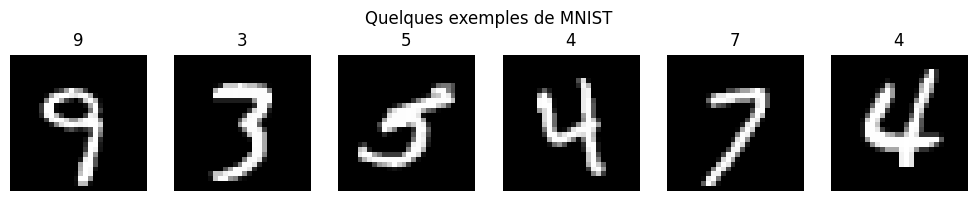

In [3]:
# on garde une partie du train pour la validation (pour surveiller l'overfitting)
n_total = len(train_dataset_full)
n_val = int(0.1 * n_total)
n_train = n_total - n_val

train_dataset, val_dataset = random_split(train_dataset_full, [n_train, n_val],
                                           generator=torch.Generator().manual_seed(0))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

print("batches d'entrainement par epoch:", len(train_loader))

# schema rapide : quelques exemples du dataset
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for i, ax in enumerate(axes):
    img, label = train_dataset[i]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(str(label))
    ax.axis("off")
plt.suptitle("Quelques exemples de MNIST")
plt.tight_layout()
plt.show()

### 1.2 Definir le modele (petit CNN)

In [4]:
class PetitCNN(nn.Module):
    def __init__(self, nb_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2)   # divise la taille par 2
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(32 * 7 * 7, nb_classes)   # 28 -> 14 -> 7 apres 2 pooling

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))   # (batch, 16, 14, 14)
        x = self.pool(self.relu(self.conv2(x)))   # (batch, 32, 7, 7)
        x = self.flatten(x)                       # (batch, 32*7*7)
        x = self.fc(x)                             # (batch, 10) — logits, une valeur par classe
        return x

modele = PetitCNN().to(device)
print(modele)

# verification rapide de shape
batch_exemple, _ = next(iter(train_loader))
sortie = modele(batch_exemple.to(device))
print("shape de sortie:", sortie.shape)   # doit etre (batch_size, 10)

PetitCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=1568, out_features=10, bias=True)
)
shape de sortie: torch.Size([64, 10])


### Fiche technique : `nn.Conv2d` et `nn.MaxPool2d`

| Parametre (`nn.Conv2d`) | Role |
|---|---|
| `in_channels` | nb de "canaux" en entree (1 pour une image en niveaux de gris, 3 pour RGB) |
| `out_channels` | nb de filtres appliques = nb de "features maps" en sortie |
| `kernel_size` | taille de la fenetre glissante qui regarde l'image (souvent 3x3 ou 5x5) |
| `padding` | ajoute des bords a 0 pour controler la taille de sortie (`padding=1` avec `kernel_size=3` garde la meme taille) |

**Analogie** : une convolution, c'est une loupe qu'on fait glisser sur toute l'image, et qui, a chaque position, resume ce qu'elle voit localement (un contour, une texture...) en un seul nombre. `out_channels`, c'est le nombre de loupes differentes qu'on utilise en parallele (une pour les contours verticaux, une pour les horizontaux, etc.) — le reseau apprend lui-meme ce que chaque loupe doit detecter.

`nn.MaxPool2d(kernel_size=2)` : reduit la taille de l'image de moitie en ne gardant que la valeur maximale de chaque bloc de 2x2. Ca rend le modele plus robuste aux petits decalages et reduit le nombre de calculs.

### 1.3 Boucle d'entrainement complete avec validation

In [5]:
def evaluer(modele, loader):
    modele.eval()
    correct, total, perte_totale = 0, 0, 0.0
    fonction_loss = nn.CrossEntropyLoss()
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            sortie = modele(x_batch)
            perte_totale += fonction_loss(sortie, y_batch).item() * x_batch.size(0)
            predictions = sortie.argmax(dim=1)
            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)
    modele.train()
    return perte_totale / total, correct / total


fonction_loss = nn.CrossEntropyLoss()   # classification multi-classe -> logits bruts en entree
optimizer = optim.Adam(modele.parameters(), lr=1e-3)

nb_epochs = 3   # volontairement petit pour que ca tourne vite en cours ; monter a 5-10 en autonomie
historique = {"train_loss": [], "val_loss": [], "val_acc": []}

for epoch in range(nb_epochs):
    perte_epoch = 0.0
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        sortie = modele(x_batch)
        loss = fonction_loss(sortie, y_batch)
        loss.backward()
        optimizer.step()

        perte_epoch += loss.item() * x_batch.size(0)

    train_loss = perte_epoch / len(train_dataset)
    val_loss, val_acc = evaluer(modele, val_loader)

    historique["train_loss"].append(train_loss)
    historique["val_loss"].append(val_loss)
    historique["val_acc"].append(val_acc)

    print(f"epoch {epoch+1}/{nb_epochs} | train_loss {train_loss:.4f} | "
          f"val_loss {val_loss:.4f} | val_acc {val_acc:.4f}")

epoch 1/3 | train_loss 0.1838 | val_loss 0.0748 | val_acc 0.9777
epoch 2/3 | train_loss 0.0581 | val_loss 0.0470 | val_acc 0.9862
epoch 3/3 | train_loss 0.0431 | val_loss 0.0463 | val_acc 0.9852


### Schema : courbes d'entrainement (train vs validation)

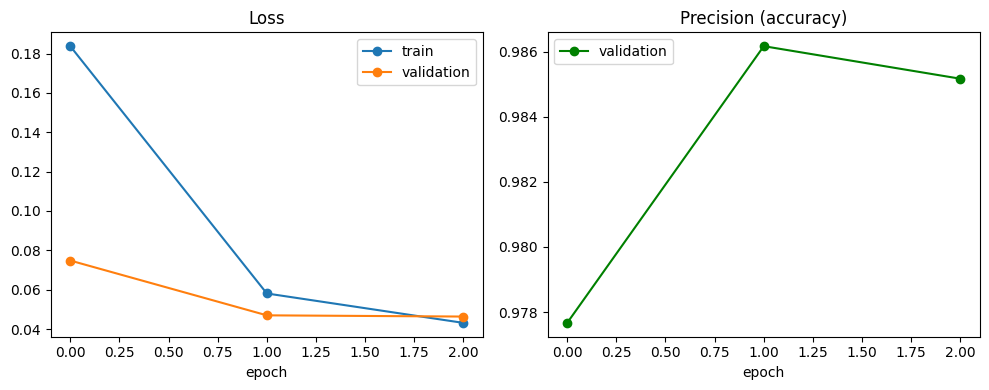

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(historique["train_loss"], label="train", marker="o")
axes[0].plot(historique["val_loss"], label="validation", marker="o")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(historique["val_acc"], label="validation", marker="o", color="green")
axes[1].set_title("Precision (accuracy)")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

# si train_loss continue de baisser mais val_loss remonte -> signe d'overfitting a surveiller

### 1.4 Evaluation finale et visualisation des predictions

loss sur le test: 0.0395 | precision sur le test: 0.9877


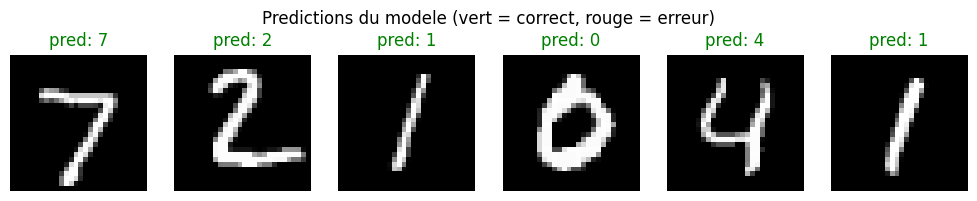

In [7]:
test_loss, test_acc = evaluer(modele, test_loader)
print(f"loss sur le test: {test_loss:.4f} | precision sur le test: {test_acc:.4f}")

# visualiser quelques predictions
modele.eval()
x_batch, y_batch = next(iter(test_loader))
with torch.no_grad():
    predictions = modele(x_batch.to(device)).argmax(dim=1).cpu()

fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(x_batch[i].squeeze(), cmap="gray")
    couleur = "green" if predictions[i] == y_batch[i] else "red"
    ax.set_title(f"pred: {predictions[i].item()}", color=couleur)
    ax.axis("off")
plt.suptitle("Predictions du modele (vert = correct, rouge = erreur)")
plt.tight_layout()
plt.show()

### 1.5 Sauvegarder le modele entraine

`state_dict()` est un dictionnaire `{nom_du_parametre: tensor}` qui contient tous les poids appris. C'est ca qu'on sauvegarde pas le code de la classe elle-meme, qu'il faut donc garder a cote (ou reimporter) pour recharger le modele.

In [8]:
torch.save(modele.state_dict(), "petit_cnn_mnist.pt")
print("modele sauvegarde")

# pour recharger plus tard (meme dans un autre script) :
modele_recharge = PetitCNN().to(device)
modele_recharge.load_state_dict(torch.load("petit_cnn_mnist.pt", map_location=device))
modele_recharge.eval()
print("modele recharge, pret pour l'inference")

modele sauvegarde
modele recharge, pret pour l'inference


C:\Users\ariel\AppData\Local\Temp\ipykernel_17172\288550798.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  modele_recharge.load_state_dict(torch.load("petit_cnn_mnist.p

## 2. Charger un modele pre-entraine avec Hugging Face

Recreer et entrainer un gros modele (langage, vision) prend des jours et des GPU puissants. En competition, on part presque toujours d'un modele **deja entraine** et on l'adapte (fine-tuning) ou on l'utilise tel quel.

Hugging Face (`transformers`) donne acces a des milliers de modeles pre-entraines en une ligne de code.

**Analogie** : au lieu de reconstruire une voiture de zero, on part d'un chassis deja fonctionnel et on ne modifie que ce dont on a besoin pour la course.

```bash
pip install transformers
```

In [ ]:
try:
    from transformers import pipeline
    HF_DISPONIBLE = True
except ImportError:
    HF_DISPONIBLE = False
    print("transformers n'est pas installe -> pip install transformers")

if HF_DISPONIBLE:
    # 'pipeline' encapsule tokenizer + modele + post-traitement en un seul appel
    classifieur_sentiment = pipeline("sentiment-analysis")
    resultats = classifieur_sentiment([
        "This course is amazing, I finally understand PyTorch!",
        "I am so confused, nothing makes sense."
    ])
    for texte, res in zip(["phrase 1", "phrase 2"], resultats):
        print(texte, "->", res)

### Fiche technique : `pipeline`, `AutoTokenizer`, `AutoModel`

| Objet | Role |
|---|---|
| `pipeline(tache, model=...)` | le plus simple : donne juste une tache (`"sentiment-analysis"`, `"image-classification"`, `"text-generation"`...) et Hugging Face choisit un modele par defaut (ou celui que tu precises) |
| `AutoTokenizer.from_pretrained(nom)` | transforme du texte brut en nombres (tokens) que le modele comprend |
| `AutoModel.from_pretrained(nom)` | charge les poids pre-entraines du modele correspondant a `nom` |

Le tokenizer et le modele doivent **toujours venir du meme `nom`** (ex: `"bert-base-uncased"` pour les deux) sinon les nombres ne correspondent a rien de coherent pour le modele.

**Analogie** : le tokenizer, c'est le traducteur qui convertit une langue humaine en langue du modele (des nombres) ; si le traducteur et le modele ne parlent pas le meme "dialecte" interne, tout devient incoherent.

In [ ]:
if HF_DISPONIBLE:
    from transformers import AutoTokenizer, AutoModel

    nom_modele = "distilbert-base-uncased"   # version allegee de BERT, plus rapide
    tokenizer = AutoTokenizer.from_pretrained(nom_modele)
    modele_hf = AutoModel.from_pretrained(nom_modele)

    entree = tokenizer("PyTorch et Hugging Face, une bonne combinaison.", return_tensors="pt")
    print("tokens:", entree["input_ids"].shape)

    with torch.no_grad():
        sortie_hf = modele_hf(**entree)
    print("shape des embeddings de sortie:", sortie_hf.last_hidden_state.shape)
    # (1, nb_tokens, taille_embedding) : un vecteur par token, pas encore une classification
    # -> pour une tache specifique (classification, etc.), on ajoute une petite tete
    #    entrainable par-dessus (souvent deja fournie par AutoModelForSequenceClassification etc.)

**Aller plus loin (semaine)** : pour du fine-tuning complet, regarder `AutoModelForSequenceClassification` (classification de texte), `AutoModelForImageClassification` (images), et la classe `Trainer` de `transformers`, qui fournit une boucle d'entrainement prete a l'emploi (equivalent haut niveau de la boucle manuelle vue dans la partie 1).

## 3. Charger un dataset / modele avec Kaggle

Beaucoup de competitions (dont potentiellement des epreuves IOAI) fournissent leurs donnees via Kaggle. `kagglehub` permet de telecharger un dataset ou un modele Kaggle en une ligne, sans manipuler manuellement de fichiers zip.

```bash
pip install kagglehub
```

Necessite un compte Kaggle et un token d'API (`kaggle.json`, a placer dans `~/.kaggle/` ou configure via variables d'environnement `KAGGLE_USERNAME` / `KAGGLE_KEY`).

In [ ]:
try:
    import kagglehub
    KAGGLE_DISPONIBLE = True
except ImportError:
    KAGGLE_DISPONIBLE = False
    print("kagglehub n'est pas installe -> pip install kagglehub")

if KAGGLE_DISPONIBLE:
    # exemple : telecharger un dataset Kaggle (remplacer par le dataset de la competition)
    chemin_dataset = kagglehub.dataset_download("zynicide/wine-reviews")
    print("dataset telecharge dans:", chemin_dataset)

    import pandas as pd
    import os
    fichiers = os.listdir(chemin_dataset)
    print("fichiers disponibles:", fichiers)
    # df = pd.read_csv(os.path.join(chemin_dataset, fichiers[0]))
    # df.head()

### Fiche technique : Hugging Face vs Kaggle, comment choisir vite

| Situation | Aller vers |
|---|---|
| La competition fournit un dataset a une URL Kaggle | `kagglehub.dataset_download(...)` |
| Besoin d'un modele pre-entraine generaliste (texte, image, audio) | `transformers` (Hugging Face) |
| La competition fournit un modele/notebook de reference sur Kaggle | `kagglehub.model_download(...)` ou `kagglehub.notebook_output_download(...)` |
| Besoin de fine-tuner rapidement avec une boucle d'entrainement prete a l'emploi | `transformers.Trainer` |

Dans le doute : **le sujet de la competition dit toujours ou se trouve la ressource** (Kaggle ou Hugging Face) le reflexe important est de savoir chercher/charger dans les deux rapidement, pas de deviner.

## 4. Section debug : trouve et corrige les bugs

Chaque cellule ci-dessous contient **au moins un bug volontaire**. Le code s'execute (ou plante) mais ne fait pas ce qu'il devrait. Objectif : lire le message d'erreur ou le comportement anormal, comprendre pourquoi, et corriger dans la cellule vide juste en dessous.

**Methode de debug recommandee** : lis TOUJOURS la derniere ligne du traceback en premier (le vrai message d'erreur), avant de remonter. Verifie en priorite : les shapes (`print(x.shape)` avant la ligne qui plante), le `dtype`, et si le modele est bien en mode `train()`/`eval()`.

### Bug 1 : le modele ne s'ameliore jamais

Ce code est cense entrainer un petit modele de regression, mais la loss ne baisse pratiquement pas. Trouve pourquoi.

In [ ]:
# BUG 1 (a corriger)
w = torch.tensor(0.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)
x_data = torch.tensor([1.0, 2.0, 3.0, 4.0])
y_data = torch.tensor([3.0, 5.0, 7.0, 9.0])   # y = 2x + 1

optimizer = optim.SGD([w, b], lr=0.01)

for epoch in range(50):
    y_pred = w * x_data + b
    loss = ((y_pred - y_data) ** 2).mean()
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print(f"epoch {epoch} | loss {loss.item():.4f} | w={w.item():.3f} b={b.item():.3f}")
# indice : que se passe-t-il si on ne remet jamais les gradients a zero ?

*Corrige le bug ici :*

In [ ]:
# ta version corrigee du Bug 1



### Bug 2 : erreur de shape au forward

Ce petit MLP est cense classifier des vecteurs de 10 features en 3 classes. L'appel plante.

In [ ]:
# BUG 2 (a corriger)
class Modele(nn.Module):
    def __init__(self):
        super().__init__()
        self.couche1 = nn.Linear(10, 32)
        self.couche2 = nn.Linear(16, 3)   # <- regarde bien les dimensions ici
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.couche1(x))
        x = self.couche2(x)
        return x

modele_bug2 = Modele()
batch = torch.randn(8, 10)
sortie = modele_bug2(batch)
print(sortie.shape)

*Corrige le bug ici :*

In [ ]:
# ta version corrigee du Bug 2



### Bug 3 : la loss est incoherente

Ce code entraine un classifieur 3 classes, mais la loss est bizarrement toujours tres elevee et n'a aucun sens.

In [ ]:
# BUG 3 (a corriger)
modele_bug3 = nn.Linear(10, 3)
fonction_loss = nn.CrossEntropyLoss()

x_batch = torch.randn(8, 10)
y_batch = torch.randint(0, 3, (8,))

logits = modele_bug3(x_batch)
probs = torch.softmax(logits, dim=1)   # <- est-ce vraiment ce qu'attend CrossEntropyLoss ?
loss = fonction_loss(probs, y_batch)
print("loss:", loss.item())
# indice : relis la fiche technique sur BCEWithLogitsLoss/CrossEntropyLoss dans le notebook precedent

*Corrige le bug ici :*

In [ ]:
# ta version corrigee du Bug 3



### Bug 4 : l'evaluation consomme trop de memoire / donne des resultats instables

Ce code evalue un modele deja entraine sur un batch de test, mais plante ou est anormalement lent sur un gros dataset, et donne un `dropout`/comportement legerement different a chaque appel.

In [ ]:
# BUG 4 (a corriger)
class ModeleAvecDropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.couche1 = nn.Linear(10, 32)
        self.dropout = nn.Dropout(0.5)
        self.couche2 = nn.Linear(32, 3)

    def forward(self, x):
        x = torch.relu(self.couche1(x))
        x = self.dropout(x)
        return self.couche2(x)

modele_bug4 = ModeleAvecDropout()
x_test = torch.randn(1000, 10)

# evaluation
sortie1 = modele_bug4(x_test)
sortie2 = modele_bug4(x_test)
print("les deux sorties sont identiques ?", torch.allclose(sortie1, sortie2))
# indice : le Dropout doit se comporter differemment a l'entrainement et a l'evaluation

*Corrige le bug ici :*

In [ ]:
# ta version corrigee du Bug 4



## 5. Exercices finaux

A faire seul, en reutilisant tout ce qui precede.

**Exercice A pipeline complet (30-40 min)**
En reprenant le pipeline de la partie 1 (Dataset -> modele -> entrainement -> validation -> sauvegarde), entraine un modele sur `torchvision.datasets.FashionMNIST` (meme format que MNIST, mais des vetements a la place de chiffres) au lieu de MNIST. Affiche les courbes train/val et la precision finale sur le test.

**Exercice B Hugging Face (15 min)**
Utilise `pipeline("sentiment-analysis")` (ou `"text-classification"`) sur une liste de 5 phrases de ton choix. Pour chaque phrase, affiche le label predit et le score de confiance. Bonus : essaie un autre modele explicitement avec `pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment")`.

**Exercice C debug chrono (15-20 min, sans aide)**
Le code ci-dessous contient **trois bugs distincts**. Trouve-les et corrige-les, en conditions d'epreuve (ne lance pas le debogueur pas a pas, lis les erreurs).

In [ ]:
# Exercice C : code avec 3 bugs a trouver
class ModeleExercice(nn.Module):
    def __init__(self):
        super().__init__()
        self.couche1 = nn.Linear(20, 64)
        self.couche2 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.couche1(x)
        x = self.couche2(x)
        return x

torch.manual_seed(0)
X = torch.randn(100, 20)
y = (X.sum(dim=1) > 0).float().unsqueeze(1)

modele_ex = ModeleExercice()
fonction_loss = nn.BCELoss()   # bug potentiel n1 : coherent avec la sortie du modele ?
optimizer = optim.Adam(modele_ex.parameters(), lr=0.01)

for epoch in range(50):
    y_pred = modele_ex(X)
    loss = fonction_loss(y_pred, y)
    optimizer.step()          # bug potentiel n2 : dans le bon ordre ?
    loss.backward()
    optimizer.zero_grad()
    if epoch % 10 == 0:
        print(epoch, loss.item())

with torch.no_grad():                       # bug potentiel n3 : bien coherent avec le modele utilise ?
    precision = (modele_ex(X) == y).float().mean()
    print("precision:", precision.item())

*Ta version corrigee de l'exercice C :*

In [ ]:
# ta version corrigee

